In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}

In [3]:
from csv import writer
import pandas as pd
import numpy as np
import math

def segment(dataset, label, seg_size, overlap):
    myFile = open('trainData_Seg.csv', 'w', newline = '')
    print("Non-overlapping Region: %s" %overlap)
    print("Segment Size: %s" %seg_size)
    with myFile:
        csv_writer = writer(myFile)
        for j, row in enumerate(dataset):
            if(len(row) < 2001):
                pos = math.ceil(len(row)/overlap)
                if(pos < math.ceil(seg_size/overlap)):
                    pos = math.ceil(seg_size/overlap)
                for itr in range(pos - math.ceil(seg_size/overlap) + 1):
                    init = itr * overlap
                    segment = [ ]
                    if(len(row[init : init + seg_size]) > 40):
                        segment.append(row[init : init + seg_size])
                        for item in label[j]:
                            segment.append(item)
                        csv_writer.writerow(segment)
    myFile.close()

def main_fun(segSize, overLap):
  dataframe = pd.read_csv('/content/gdrive/My Drive/DNA_RNA(Group_I7)/train_dataset.txt', header=None)
  dataset = dataframe.values
  print('Original Dataset Size : %s' %len(dataset))
  X = dataset[:,0]
  Y = dataset[:,1:len(dataset[0])]                  # 4-class problem

  DRBP_Y = np.sum(Y[:, 0:3], axis = -1)
  Y1 = np.column_stack((DRBP_Y, Y[:,3]))            # 2-class problem
  print("DRBP_Y= ",DRBP_Y)
  print("DRBP_Y= ",DRBP_Y.sum())
  print("Non_NABPs= ",Y1.sum()-DRBP_Y.sum())
  print("Y1= ",Y1)
  print("Y1= ",Y1.sum())
  segment(X, Y1, segSize, overLap)

In [4]:
import numpy as np
import math
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
np.random.seed(7)

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, seq_len, embed_dim, w_size, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.w_size = w_size
        if embed_dim % num_heads != 0:
            raise ValueError(f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def create_window_mask(self, seq_len, w_size):
        mat = np.ones((seq_len, seq_len))
        for index in range(seq_len):
            for j in range(max(0, index - w_size), min(index + w_size + 1, seq_len)):
                mat[index][j] = 0
        tensor = tf.convert_to_tensor(mat)
        return tf.cast(tensor, tf.bool)

    def attention(self, query, key, value, mask):
        score = tf.matmul(query, key, transpose_b=True)                         # Calculate attention.
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)

        # Implement Masking.
        if self.w_size is not None and mask is not None:
            win_mask = self.create_window_mask(self.seq_len, self.w_size)        # Compute window mask.
            int_mask = tf.math.logical_or(tf.cast(mask[0], tf.bool), win_mask)   # Combine pad mask and window mask.
            int_mask = tf.math.logical_or(tf.cast(mask[1], tf.bool), tf.cast(int_mask, tf.bool))
            final_mask = tf.cast(int_mask, tf.float32)
            scaled_score += (final_mask * -1e5)
        elif mask is not None:                                                     # add the mask to the scaled tensor.
            final_mask = mask[0]
            scaled_score += (final_mask * -1e5)                                    # mask: Float tensor (..., seq_len_q, seq_len_k).

        weights = tf.nn.softmax(scaled_score, axis=-1)
        max_wt = tf.reduce_max(weights, axis = -1)
        scaled_weights = tf.divide(weights, max_wt[:,:,:,tf.newaxis])             # Scaled SOFTMAX
        reverse_final_mask = 1.0 - final_mask
        scaled_weights = tf.multiply(scaled_weights, reverse_final_mask) + 0.001  # Re-apply mask
        output = tf.matmul(scaled_weights, value)
        return output, scaled_weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, mask):
        # x.shape = [batch_size, seq_len, embedding_dim]
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)                                        # (batch_size, seq_len, embed_dim)
        key = self.key_dense(inputs)                                            # (batch_size, seq_len, embed_dim)
        value = self.value_dense(inputs)                                        # (batch_size, seq_len, embed_dim)
        query = self.separate_heads(query, batch_size)                          # (batch_size, num_heads, seq_len, projection_dim)
        key = self.separate_heads(key, batch_size)                              # (batch_size, num_heads, seq_len, projection_dim)
        value = self.separate_heads(value, batch_size)                          # (batch_size, num_heads, seq_len, projection_dim)
        attention, weights = self.attention(query, key, value, mask)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])                             # (batch_size, seq_len, num_heads, projection_dim)
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))         # (batch_size, seq_len, embed_dim)
        output = self.combine_heads(concat_attention)                                      # (batch_size, seq_len, embed_dim)
        return output, weights

class TransformerBlock(layers.Layer):
    def __init__(self, seq_len, embed_dim, num_heads, ff_dim, w_size, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.w_size = w_size
        self.att = MultiHeadSelfAttention(seq_len, embed_dim, w_size, num_heads)          # Sub-layer 1
        self.ffn = keras.Sequential([layers.Dense(ff_dim, kernel_initializer='normal', activation="relu"),    # Sub-layer 2
                                     layers.Dense(embed_dim, kernel_initializer='normal'),])                  # Two linear transformations with ReLU activation in between.
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate=0.2)
        self.dropout2 = layers.Dropout(rate=0.2)

    def call(self, inputs, mask, training=True):                                           # Main transformer block
        attn_output, attn_wt = self.att(inputs, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output), attn_wt

    def get_config(self):
        config = super().get_config().copy()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads, 'ff_dim': self.ff_dim,
                       'seq_len': self.seq_len, 'w_size': self.w_size})
        return config

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, emded_dim, **kwargs):
        super(TokenAndPositionEmbedding, self).__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.emded_dim = emded_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=emded_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=emded_dim)
        self.dropout1 = layers.Dropout(rate=0.3)
        self.dropout2 = layers.Dropout(rate=0.3)

    def create_padding_mask(self, seq):
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)    # add extra dimensions to add the padding to the attention logits.
        return seq[:, tf.newaxis, tf.newaxis, :], seq[:, tf.newaxis, :, tf.newaxis]
        # return (batch_size, 1, 1, seq_len), (batch_size, 1, seq_len, 1)

    def call(self, x, training=True):
        padding_mask = self.create_padding_mask(x)

        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        positions = self.dropout1(positions, training=training)
        x = self.token_emb(x)
        x = self.dropout2(x, training=training)
        return x + positions, padding_mask

    def get_config(self):
        config = super().get_config().copy()
        config.update({'maxlen': self.maxlen, 'vocab_size': self.vocab_size,'emded_dim': self.emded_dim,})
        return config

In [5]:
def dictionary(chunk_size):
    dataframe = pd.read_csv("/content/gdrive/My Drive/DNA_RNA(Group_I7)/train_dataset.txt", header=None)
    dataset = dataframe.values
    seq_dataset = dataset[:,0]
    print('Creating Dictionary:')
    dict = {}
    j = 0
    for row in seq_dataset:
        for i in range(len(row) - chunk_size + 1):
            key = row[i:i + chunk_size]
            if key not in dict:
                dict[key] = j
                j = j + 1
    del dataframe, dataset, seq_dataset
    return(dict)

def nGram(dataset, chunk_size, dictI):
    dict1 = list()
    for j, row in enumerate(dataset):
        string = row
        dict2 = list()
        for i in range(len(string) - chunk_size + 1):
            try:
                dict2.append(dictI[string[i:i + chunk_size]])
            except:
                None
        dict1.append(dict2)
    return(dict1)

def create_rec_model1(top_words, seq_len, o_dim):
    embedding_vecor_length = 16          # Embedding size for each token
    num_heads = 4                        # Number of attention heads
    ff_dim = 32                          # Hidden layer size in feed forward network inside transformer

    inputs = layers.Input(shape=(seq_len,))
    embedding_layer = TokenAndPositionEmbedding(seq_len, top_words, embedding_vecor_length)
    x, pad_mask = embedding_layer(inputs)
    x = layers.Dropout(0.3)(x)

    transformer_block1 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, seq_len)              # seq_len
    x1, attn_score1 = transformer_block1(x, pad_mask)

    transformer_block2 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, int(seq_len/2))       # (seq_len / 2)
    x2, attn_score2 = transformer_block2(x, pad_mask)

    transformer_block3 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, int(seq_len/4))       # (seq_len / 4)
    x3, attn_score3 = transformer_block3(x, pad_mask)

    x = layers.Concatenate(axis = -1)([x1, x2, x3])
    x = layers.Dense(24)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(o_dim, kernel_initializer='normal', activation='softmax')(x)

    r_model = keras.Model(inputs=[inputs], outputs=[outputs])

    #adam = keras.optimizers.Adam(learning_rate=0.0005)
    opt = keras.optimizers.Adamax(learning_rate=0.0005)
    r_model.compile(loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0), optimizer=opt, metrics=['accuracy'])
    return r_model

def class_weight(train_y):
    DRBP_Y = np.sum(train_y[:, 0], axis = -1)
    NonDRBP_Y = np.sum(train_y[:, 1], axis = -1)
    print(DRBP_Y, NonDRBP_Y)
    norm_DRBP_Y = NonDRBP_Y/(DRBP_Y + NonDRBP_Y)
    norm_NonDRBP_Y = DRBP_Y/(DRBP_Y + NonDRBP_Y)

    class_weight = {0: norm_DRBP_Y/norm_DRBP_Y, 1: (norm_NonDRBP_Y/norm_DRBP_Y)}
    return class_weight

# CREATING DICTIONARY
chunkSize = 4
dict_Prop = dictionary(chunkSize)

# Preparing For Training
segmentSize = 300             # 150, 200, 250
nonOL = 150
SEG = str(segmentSize)
main_fun(segmentSize, nonOL)                                       # Create segments
dataframe = pd.read_csv("trainData_Seg.csv", header=None)
dataset = dataframe.values

X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])].astype(None)
nb_of_cls = len(Y[0])
del dataframe, dataset

class_weight = class_weight(Y)
print(class_weight)

#Split the dataset
x_train, x_validate, y_train, y_validate = train_test_split(X, Y, test_size = 0.1, random_state = 42)
del X, Y

#CREATING N-GRAM
x_train = nGram(x_train, chunkSize, dict_Prop)
x_validate = nGram(x_validate, chunkSize, dict_Prop)

# truncate and pad input sequences
max_seq_len = segmentSize - chunkSize + 1
x_train = keras.utils.pad_sequences(x_train, maxlen=max_seq_len)
x_validate = keras.utils.pad_sequences(x_validate, maxlen=max_seq_len)

# Create & Compile the model
model = create_rec_model1(len(dict_Prop), max_seq_len, nb_of_cls)
print(model.summary())
early_stopping_monitor1 = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 4, verbose = 1)
history = model.fit(x_train, y_train,
          validation_data = (x_validate, y_validate),
          epochs = 1000,
          batch_size = 128,
          #class_weight = class_weight,
          shuffle=True,
          callbacks=[early_stopping_monitor1],
          verbose=1)

Creating Dictionary:
Original Dataset Size : 10966
DRBP_Y=  [1 1 1 ... 0 0 0]
DRBP_Y=  6791
Non_NABPs=  4175
Y1=  [[1 0]
 [1 0]
 [1 0]
 ...
 [0 1]
 [0 1]
 [0 1]]
Y1=  10966
Non-overlapping Region: 150
Segment Size: 300
20701.0 9959.0
{0: np.float64(1.0), 1: np.float64(2.078622351641731)}


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 297)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ [(None, 297, 16), │  2,535,888 │ input_layer[0][0] │
│ (TokenAndPositionE… │ (None, 1, 1,      │            │                   │
│                     │ 297), (None, 1,   │            │                   │
│                     │ 297, 1)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 297, 16)   │          0 │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ [(None, 297, 16), │      2,224 │ dropout_2[0][0],  │
│ (TransformerBlock)  │ (None, 4, 297,    │            │ token_and_positi… │
│                     │ 297)]             │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ [(None, 297, 16), │      2,224 │ dropout_2[0][0],  │
│ (TransformerBlock)  │ (None, 4, 297,    │            │ token_and_positi… │
│                     │ 297)]             │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ [(None, 297, 16), │      2,224 │ dropout_2[0][0],  │
│ (TransformerBlock)  │ (None, 4, 297,    │            │ token_and_positi… │
│                     │ 297)]             │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 297, 48)   │          0 │ transformer_bloc… │
│ (Concatenate)       │                   │            │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 297, 24)   │      1,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 297, 24)   │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 24)        │          0 │ dropout_9[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 24)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 2)         │         50 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,543,786 (9.70 MB)

 Trainable params: 2,543,786 (9.70 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 297))
  warnings.warn(msg)


216/216 ━━━━━━━━━━━━━━━━━━━━ 59s 182ms/step - accuracy: 0.6462 - loss: 0.0417 - val_accuracy: 0.6624 - val_loss: 0.0380
Epoch 2/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.7065 - loss: 0.0362 - val_accuracy: 0.7688 - val_loss: 0.0312
Epoch 3/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.7835 - loss: 0.0298 - val_accuracy: 0.7893 - val_loss: 0.0301
Epoch 4/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8238 - loss: 0.0258 - val_accuracy: 0.8118 - val_loss: 0.0285
Epoch 5/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.8590 - loss: 0.0219 - val_accuracy: 0.8294 - val_loss: 0.0269
Epoch 6/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.8830 - loss: 0.0184 - val_accuracy: 0.8363 - val_loss: 0.0282
Epoch 7/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.9017 - loss: 0.0161 - val_accuracy: 0.8483 - val_loss: 0.0261
Epoch 8/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.9183 - loss

In [6]:
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, matthews_corrcoef, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc, recall_score

def final_model(filename, overlap = 30):
    print('Extracting features based on LSTM model...... ')
    dataframe2 = pd.read_csv(filename, header=None)
    dataset2 = dataframe2.values
    X_test, Y_test = dataset2[:,0], dataset2[:,1:len(dataset2[0])]
    c_p = []
    for tag, row in enumerate(X_test):
        pos = math.ceil(len(row) / overlap)
        if(pos < math.ceil(segmentSize/ overlap)):
            pos = math.ceil(segmentSize/ overlap)
        segment = [ ]
        for itr in range(pos - math.ceil(segmentSize/overlap) + 1):
            init = itr * overlap
            segment.append(row[init : init + segmentSize])
        seg_nGram = nGram(segment, chunkSize, dict_Prop)
        test_seg = keras.utils.pad_sequences(seg_nGram, maxlen=max_seq_len)
        preds = model.predict(test_seg, verbose = 0)
        c_p.append(np.mean(preds, axis=0))
    c_p = np.array(c_p)
    return c_p, Y_test

def ratio_recall_curve(labels1, cross_label, scores):
    tpr, cro, thr = [], [], []
    for c in np.arange(1.0, -0.001, -0.0005):
        pred_labels = []
        for e in scores:
            if e >= c:
                pred_labels.append(1.0)
            else:
                pred_labels.append(0.0)
        tpr.append(recall_score(labels1, pred_labels))
        cro.append(recall_score(cross_label, pred_labels))
        thr.append(c)
    return tpr, cro, thr

def aurc_and_laurc_score(true_label, cross_label, tpred_scores11):
    tprs, cros, ths = ratio_recall_curve(true_label, cross_label, tpred_scores11)
    aurc = auc(tprs, cros)
    return aurc

# Creates a HDF5 file 'my_model.h5'
#model_path = '/content/gdrive/My Drive/DNA_RNA(Group_I7)/MCWS_Transformer/Weighted/3.32.model_'+str(nonOL)+'_'+ SEG +'.h5'
#model.save(model_path)
#del model
#model = load_model(model_path)

# **TEST474 DATASET**

Extracting features based on LSTM model...... 


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(31, 297))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 297))
  warnings.warn(msg)


(474, 2) (474, 4)
(474, 2) (474, 2)
(474,) (474,)
Confusion Matrix:  [[227  24]
 [ 77 146]]
MCC SCORE:  0.5818493231726097
Recall: 77.9545495149447      Precision: 80.27670278637771      F1-score2: 78.05102812736399      Support: None
Recall: 78.69198312236287      Precision: 78.69198312236287      F1-score2: 78.69198312236287      Support: None


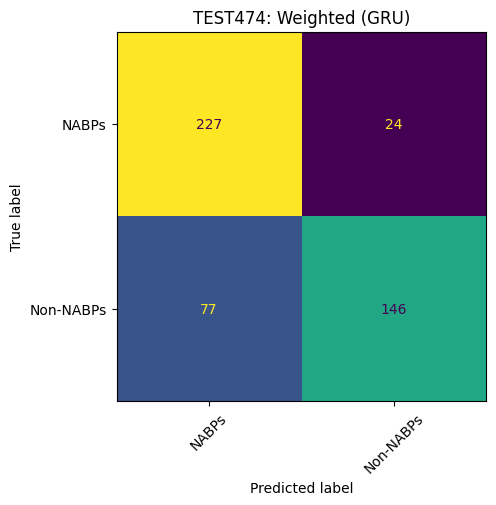

In [7]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)                        # Y_true.shape = 4

    DRBP_Y = np.sum(Y_true[:, 0:3], axis = -1)
    Y1 = np.column_stack((DRBP_Y, Y_true[:,3]))            # 2-class problem
    print(Y_Pred.shape, Y1.shape)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y1 = np.argmax(Y1, axis=1)
    print(Y_Pred.shape, Y1.shape)

    cm = confusion_matrix(Y1, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("TEST474: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y1, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y1, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y1, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/My Drive/DNA_RNA(Group_I7)/Test_Folder/TEST474_test.txt")


# **DRBP206_test DATASET**

Extracting features based on LSTM model...... 
(206, 2) (206, 4)
(206,) (206,)
Confusion Matrix:  [[102   1]
 [ 69  34]]
MCC SCORE:  0.4265617038812147
Recall: 66.01941747572816      Precision: 78.39598997493734      F1-score2: 61.86395853168306      Support: None
Recall: 66.01941747572816      Precision: 66.01941747572816      F1-score2: 66.01941747572816      Support: None


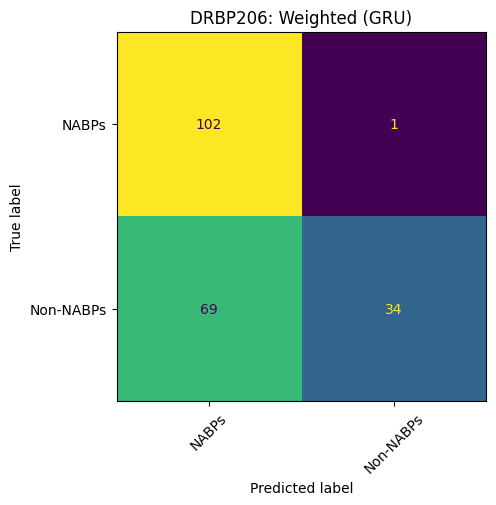

In [8]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)                 # (206, 2) (206, 4)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y_true = np.argmax(Y_true[:, 2:], axis=1)
    print(Y_Pred.shape, Y_true.shape)

    cm = confusion_matrix(Y_true, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("DRBP206: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y_true, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/My Drive/DNA_RNA(Group_I7)/Test_Folder/DRBP206_test.txt")

# **PDB255_test DATASET**

Extracting features based on LSTM model...... 
(255, 2) (255, 4)
(255, 2) (255, 2)
(255,) (255,)
Confusion Matrix:  [[115  48]
 [ 53  39]]
MCC SCORE:  0.13110629733321433
Recall: 56.47172579354495      Precision: 56.63998357963875      F1-score2: 56.530911914125134      Support: None
Recall: 60.3921568627451      Precision: 60.3921568627451      F1-score2: 60.3921568627451      Support: None


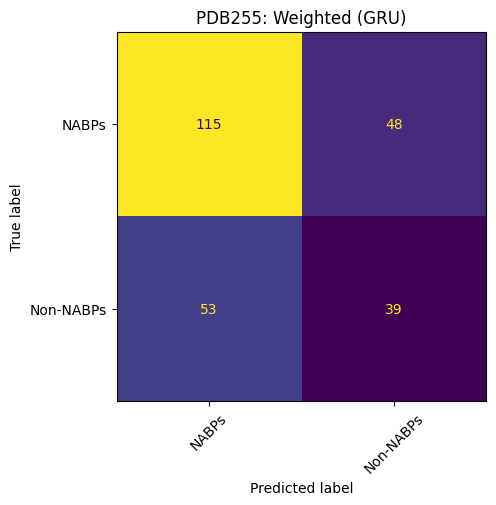

In [9]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)

    DRBP_Y = np.sum(Y_true[:, 0:2], axis = -1)
    Y1 = np.column_stack((DRBP_Y, Y_true[:,3]))            # 2-class problem
    print(Y_Pred.shape, Y1.shape)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y_true = np.argmax(Y1, axis=1)
    print(Y_Pred.shape, Y_true.shape)

    cm = confusion_matrix(Y_true, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("PDB255: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y_true, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/My Drive/DNA_RNA(Group_I7)/Test_Folder/PDB255_test.txt")